In [ ]:
from lgdo import lh5
import numpy as np
import matplotlib.pyplot as plt
from pytools4scarf.utils import minmax, load_yaml
import dspeed
import tol_colors as tc

plt.style.use("/mnt/atlas01/users/vogl/style/phd_style/phd_thesis.mplstyle")
plot_loc = "../plots/phd/"

raw_file = "/mnt/atlas01/projects/scarf/data/sp01/prodenv/ref-raw/generated/tier/raw/cal/p00/r037/sp01-p00-r037-cal-20231026T180002Z-tier_raw.lh5"
dsp_file = "/mnt/atlas01/users/vogl/scarf/sp01/data/dsp_v9-0/cal/p00/r037/sp01-p00-r037-cal-20231026T180002Z-tier_dsp.lh5"

dsp_config = load_yaml("/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/ged_dsp_conf.yaml")
dsp_database = load_yaml("/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/dsp_database_general.yaml")

dsp_config["outputs"].extend(["wf_blsub", "wf_pz", "wf_single_pz", "wf_blsub_win", "wf_pz_win", "wf_single_pz_win",
                              "wf_etrap", "wf_etrap_fix", "wf_atrap_win", "tp_start",
                              "curr_win", "curr_up_win", "curr_av_win", "wf_tri", "wf_mwavg_win", "wf_mwavg_up_win", "wf_mwavg_up_curr_win",
                              "Iasy_threshold"
                              ])
dsp_config["processors"]["wf_single_pz"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub", "db.pz.tau1", "wf_single_pz"],
    "unit": "ADC",
}
dsp_config["processors"]["wf_single_pz_win"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub_win", "db.pz.tau1", "wf_single_pz_win"],
    "unit": "ADC",
}

/tmp/ipykernel_749983/2302428819.py:1: DeprecationWarning: lgdo.lh5 has moved to its own package, legend-lh5io. Please replace 'import lgdo.lh5' with 'import lh5'. lgdo.lh5 will be removed in a future release.
  from lgdo import lh5
/mnt/atlas02/users/leoli/.conda/envs/leolienv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Plotting a raw waveform

In [7]:
raw_df = lh5.read(name="ch002/raw",
               lh5_file=raw_file,
            #    n_rows=100
               ).view_as("pd")

In [8]:
raw_df.timestamp

0        1.698336e+09
1        1.698336e+09
2        1.698336e+09
3        1.698336e+09
4        1.698336e+09
             ...     
51264    1.698338e+09
51265    1.698338e+09
51266    1.698338e+09
51267    1.698338e+09
51268    1.698338e+09
Name: timestamp, Length: 51269, dtype: float64

In [9]:
i = 7
ts_presummed_values = np.arange(0, 160, 0.04)
ts_windowed_values = np.linspace(75, 85, 1001)

In [10]:
ts_presummed_values

array([0.0000e+00, 4.0000e-02, 8.0000e-02, ..., 1.5988e+02, 1.5992e+02,
       1.5996e+02], shape=(4000,))

Text(0, 0.5, 'ADC channels (a.u.)')

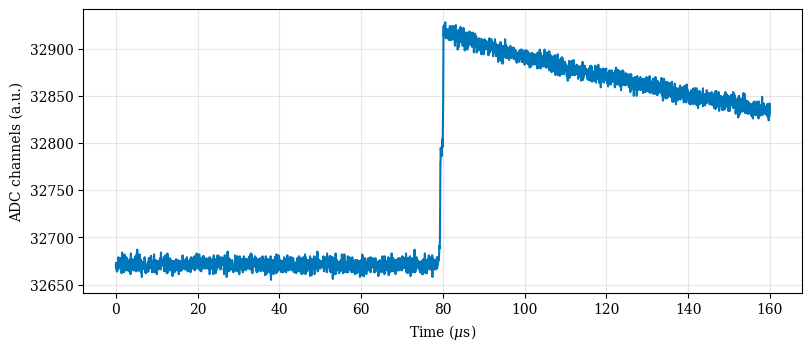

In [11]:
fig, ax = plt.subplots()

ax.plot(ts_presummed_values, raw_df.waveform_presummed_values[i])
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")

In [12]:
ts_windowed_values

array([75.  , 75.01, 75.02, ..., 84.98, 84.99, 85.  ], shape=(1001,))

Text(0, 0.5, 'ADC channels (a.u.)')

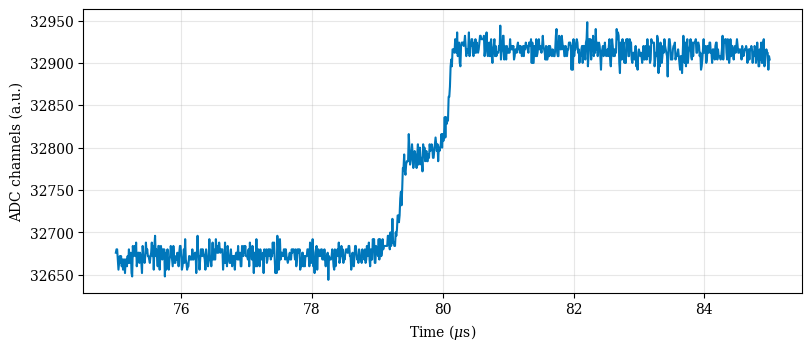

In [13]:
fig, ax = plt.subplots()
ax.plot(ts_windowed_values, raw_df.waveform_windowed_values[i])
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")

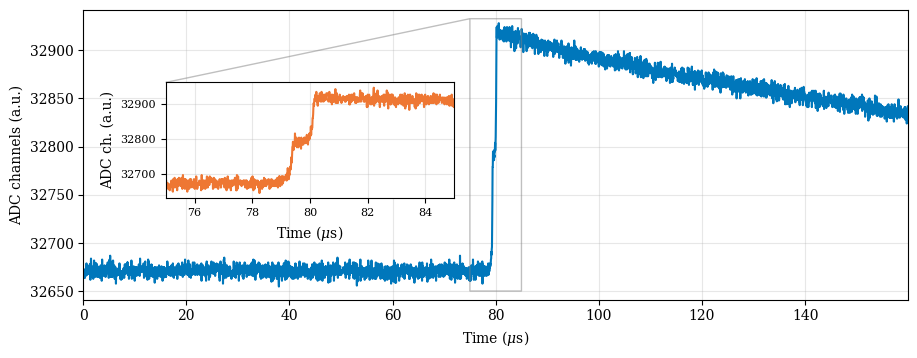

In [8]:
fig, ax = plt.subplots()

# Main plot: presummed waveform
ax.plot(ts_presummed_values, raw_df.waveform_presummed_values[i])
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_presummed_values))

# Inset: windowed waveform
ax_inset = ax.inset_axes([0.1, 0.35, 0.35, 0.4])  # [x, y, width, height] in axes coordinates
ax_inset.plot(ts_windowed_values, raw_df.waveform_windowed_values[i], color="C1")
ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("ADC ch. (a.u.)", fontsize=10)
ax_inset.tick_params(labelsize=8)
ax_inset.set_xlim(minmax(ts_windowed_values))

# Draw indicator box with custom bounds [x0, y0, width, height] in data coordinates
wf_min, wf_max = ax.get_ylim()
margin = 0.03 * (wf_max - wf_min)  # 10% margin from top and bottom
bounds = [ts_windowed_values[0], wf_min + margin, 
          ts_windowed_values[-1] - ts_windowed_values[0], (wf_max - margin) - (wf_min + margin)]
inset_indicator = ax.indicate_inset(bounds, inset_ax=ax_inset, edgecolor="gray")
connectors = inset_indicator.connectors

# Connector lines: 0=lower-left, 1=upper-left, 2=lower-right, 3=upper-right
# Show bottom-left and top-right connectors, hide bottom-right and top-left
connectors[0].set_visible(False)  # lower-left
connectors[1].set_visible(True)  # upper-left
connectors[2].set_visible(False)  # lower-right
connectors[3].set_visible(False)  # upper-right

fig.tight_layout()
# fig.savefig(plot_loc+"example_waveforms_with_inset.pdf")

## Showing DSP parameters on waveform

In [9]:
dsp_df = lh5.read(name="ch002/dsp",
               lh5_file=dsp_file,
               n_rows=100
               ).view_as("pd")

In [10]:
xwidth = 20
i = 13

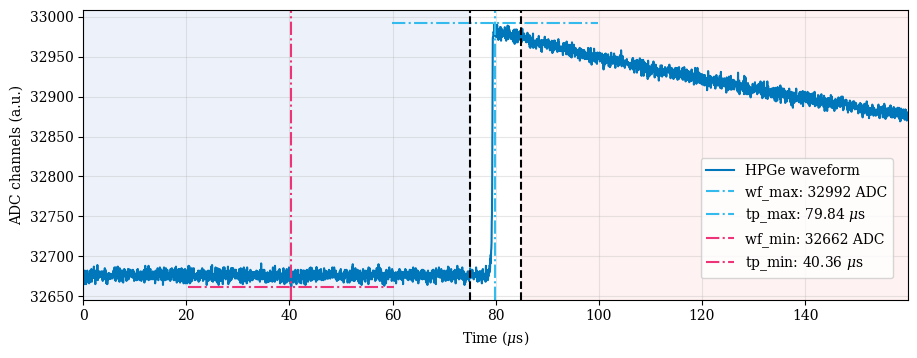

In [11]:
fig, ax = plt.subplots()

ax.plot(ts_presummed_values, raw_df.waveform_presummed_values[i], label="HPGe waveform")

ax.hlines(dsp_df.wf_max[i], xmin=dsp_df.tp_max[i]/1e3-xwidth, xmax=dsp_df.tp_max[i]/1e3+xwidth, label=f"wf_max: {int(dsp_df.wf_max[i])} ADC" , ls="-.", color="C2")
ax.axvline(dsp_df.tp_max[i]/1e3, label=fr"tp_max: {dsp_df.tp_max[i]/1e3} $\mu$s" , ls="-.", color="C2")

ax.hlines(dsp_df.wf_min[i], xmin=dsp_df.tp_min[i]/1e3-xwidth, xmax=dsp_df.tp_min[i]/1e3+xwidth, label=f"wf_min: {int(dsp_df.wf_min[i])} ADC" , ls="-.", color="C3")
ax.axvline(dsp_df.tp_min[i]/1e3, label=fr"tp_min: {dsp_df.tp_min[i]/1e3} $\mu$s" , ls="-.", color="C3")

# Shaded regions (Tol pale)
ax.axvspan(0, ts_presummed_values[1875], alpha=0.25, color=tc.pale[0])
ax.axvspan(ts_presummed_values[2125], ts_presummed_values[-1], alpha=0.25, color=tc.pale[1])
ax.axvline(ts_presummed_values[1875], color="black", ls="--")
ax.axvline(ts_presummed_values[2125], color="black", ls="--")

ax.legend(loc='lower right', bbox_to_anchor=(0.99, 0.05))
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_presummed_values))

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_with_general_dsp_pars.pdf")

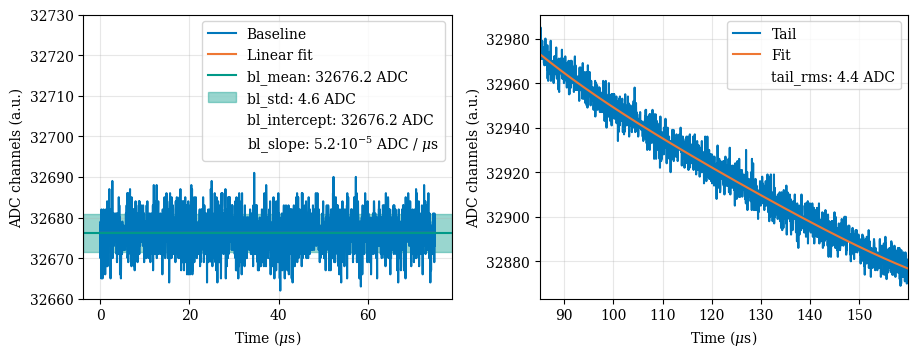

In [12]:
fig, axs = plt.subplots(ncols=2)

# left panel: baseline
axs[0].plot(ts_presummed_values[:1875], raw_df.waveform_presummed_values[i][:1875], label="Baseline")
axs[0].plot(ts_presummed_values[:1875], dsp_df.bl_intercept[i] + dsp_df.bl_slope[i] * ts_presummed_values[:1875], label="Linear fit")

axs[0].axhline(dsp_df.bl_mean[i], label=f"bl_mean: {round(dsp_df.bl_mean[i], 1)} ADC" , color="C5")
axs[0].axhspan(dsp_df.bl_mean[i] - dsp_df.bl_std[i], dsp_df.bl_mean[i] + dsp_df.bl_std[i], 
           alpha=0.4, color="C5", label=f"bl_std: {round(dsp_df.bl_std[i], 1)} ADC")
axs[0].plot([], [], ' ', label=f"bl_intercept: {round(dsp_df.bl_intercept[i], 1)} ADC")
axs[0].plot([], [], ' ', label=f"bl_slope: {round(dsp_df.bl_slope[i]*1e5, 1)}"+r"$\cdot 10^{-5}$ ADC / $\mu$s")
axs[0].set_ylim(32660, 32730)
axs[0].set_xlabel(r"Time ($\mu$s)")
axs[0].set_ylabel("ADC channels (a.u.)")
axs[0].legend()

# right panel tail
axs[1].plot(ts_presummed_values[2125:], raw_df.waveform_presummed_values[i][2125:], label="Tail")
axs[1].plot(ts_presummed_values[2125:], np.exp(np.sum([np.arange(0, 4000-2125)**j * dsp_df.tail_pars[i][j] for j in range(5)], axis=0)), 
        label="Fit")
axs[1].plot([], [], " ", label=f"tail_rms: {round(dsp_df.tail_rms[i], 1)} ADC")

axs[1].set_xlim(minmax(ts_presummed_values[2125:]))
axs[1].set_xlabel(r"Time ($\mu$s)")
axs[1].set_ylabel("ADC channels (a.u.)")
axs[1].legend()

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_with_baseline_and_tail_dsp_pars.pdf")

## Pole-zero correction

In [13]:
proc_df = dspeed.build_dsp(
    raw_in=raw_file,
    lh5_tables="ch002",
    dsp_config=dsp_config,
    database=dsp_database,
    n_entries=100
)
proc_tb = proc_df["ch002"]["dsp"]

In [14]:
i = 55

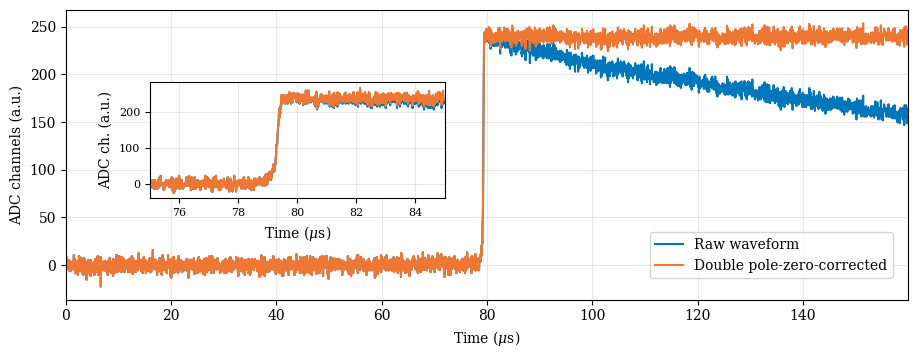

In [15]:
fig, ax = plt.subplots()

ax.plot(ts_presummed_values, proc_tb.wf_blsub.values[i], label="Raw waveform")
#ax.plot(ts_presummed_values, proc_tb.wf_single_pz.values[i], label="Single pole-zero-corrected")
ax.plot(ts_presummed_values, proc_tb.wf_pz.values[i], label="Double pole-zero-corrected")

# Inset: windowed waveform
ax_inset = ax.inset_axes([0.1, 0.35, 0.35, 0.4])  # [x, y, width, height] in axes coordinates
ax_inset.plot(ts_windowed_values, proc_tb.wf_blsub_win.values[i])
#ax_inset.plot(ts_windowed_values, proc_tb.wf_single_pz_win.values[i])
ax_inset.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i])
ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("ADC ch. (a.u.)", fontsize=10)
ax_inset.tick_params(labelsize=8)
ax_inset.set_xlim(minmax(ts_windowed_values))

ax.legend(loc='lower right', bbox_to_anchor=(0.99, 0.05))
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_presummed_values))

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_with_pz_correction.pdf")

## Energy estimation

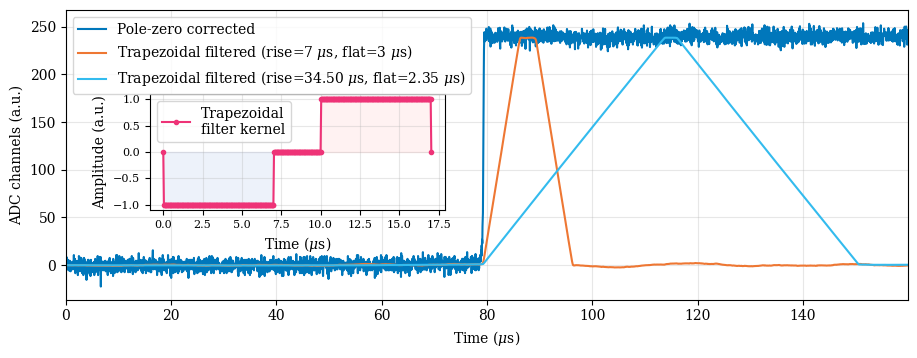

In [16]:
rise = 7
flat = 3
padding = 0
dt = 0.04
height=1
shift = 0

kernel = np.array(
    [0]*int(padding/2/dt-shift+1) + [-height]*int(rise/dt) + [0]*int(flat/dt) + [+height]*int(rise/dt) + [0]*int(padding/2/dt+1+shift)
)

fig, ax = plt.subplots()

ax.plot(ts_presummed_values, proc_tb.wf_pz.values[i], label="Pole-zero corrected")
ax.plot(ts_presummed_values, proc_tb.wf_etrap_fix.values[i], label="Trapezoidal filtered"+r" (rise=7 $\mu$s, flat=3 $\mu$s)")
ax.plot(ts_presummed_values, proc_tb.wf_etrap.values[i], label="Trapezoidal filtered"+r" (rise=34.50 $\mu$s, flat=2.35 $\mu$s)")

ax_inset = ax.inset_axes([0.1, 0.31, 0.35, 0.4])  # [x, y, width, height] in axes coordinates
ax_inset.plot(np.arange(0, len(kernel), 1)*dt, kernel, color="C3", marker='.', label="Trapezoidal\nfilter kernel")
ax_inset.fill_between([0, 7], [0, 0], [-1, -1], color=tc.pale[0], alpha=0.25)
ax_inset.fill_between([10, 17], [0, 0], [1, 1], color=tc.pale[1], alpha=0.25)

ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("Amplitude (a.u.)")
ax_inset.tick_params(labelsize=8)
ax_inset.legend()

ax.legend(loc='upper left')
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_presummed_values))

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_with_trap_filters.pdf")

## $t_0$ estimation

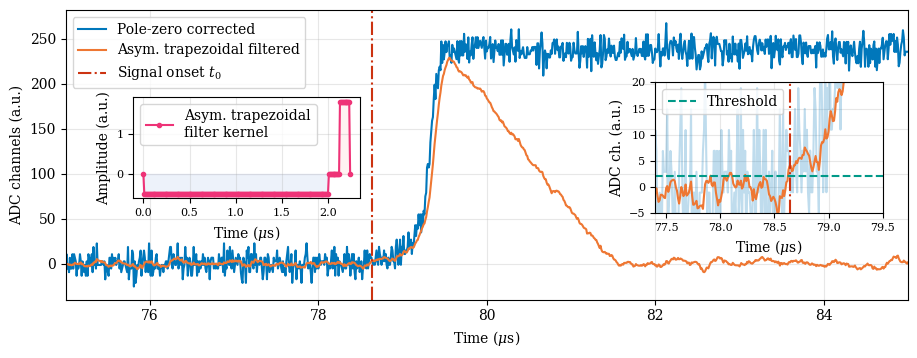

In [17]:
rise = 0.11
flat = 0.12
fall = 2
padding = 0
dt = 0.01
height_fall = 1/fall
height_rise = 1/rise/5
shift = 0

kernel = np.array(
    [0]*int(padding/2/dt-shift+1) + [-height_fall]*int(fall/dt) + [0]*int(flat/dt) + [+height_rise]*int(rise/dt) + [0]*int(padding/2/dt+1+shift)
)

fig, ax = plt.subplots()

# main panel
ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], label="Pole-zero corrected")
ax.plot(ts_windowed_values, proc_tb.wf_atrap_win.values[i], label="Asym. trapezoidal filtered")
#ax.axvline(proc_tb.tp_start[i]/1e3, ls="-.")
ax.axvline(proc_tb.tp_0_atrap[i]/1e3, ls="-.", color="C4", label=r"Signal onset $t_0$")

ax.legend(loc='upper left')
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))

# inset 1 - filter kernel
ax_inset = ax.inset_axes([0.08, 0.35, 0.27, 0.35])  # [x, y, width, height] in axes coordinates
ax_inset.plot(np.arange(0, len(kernel), 1)*dt, kernel, color="C3", marker='.', label="Asym. trapezoidal\nfilter kernel")
ax_inset.set_ylim(None, None)
ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("Amplitude (a.u.)")
ax_inset.tick_params(labelsize=8)
ax_inset.fill_between([0, fall], [0, 0], [-height_fall, -height_fall], color=tc.pale[0], alpha=0.25)
ax_inset.fill_between([fall+flat, rise+flat+fall], [0, 0], [height_rise, height_rise], color=tc.pale[1], alpha=0.25)

# inset 2 - signal onset
ax_inset.legend()
ax_inset2 = ax.inset_axes([0.7, 0.30, 0.27, 0.45])  # [x, y, width, height] in axes coordinates
ax_inset2.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], alpha=0.25)
ax_inset2.plot(ts_windowed_values, proc_tb.wf_atrap_win.values[i])
ax_inset2.axvline(proc_tb.tp_0_atrap[i]/1e3, ls="-.", color="C4")
ax_inset2.axhline(2, ls="--", color="C5", label="Threshold")
ax_inset2.set_xlim(77.4, 79.5)
ax_inset2.set_ylim(-5, 20)
ax_inset2.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset2.set_ylabel("ADC ch. (a.u.)", fontsize=10)
ax_inset2.tick_params(labelsize=8)
ax_inset2.legend()

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_for_t0_estimation.pdf")

## Current estimation

### A_max

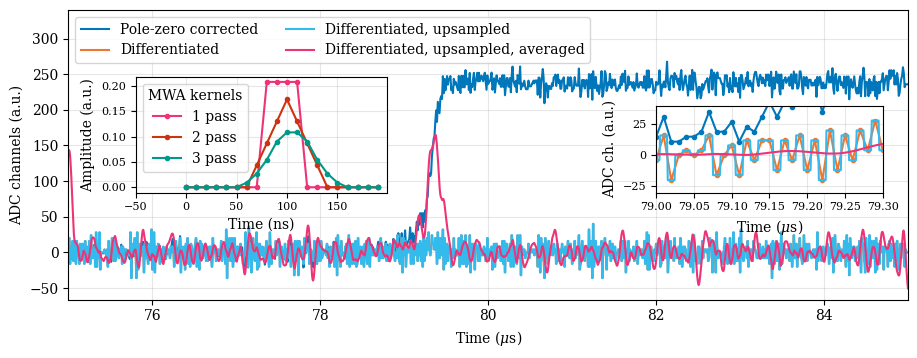

In [18]:
length = 0.048
height = dt/length
padding = 8
n_convolutions = 2

one_pass_kernel = np.array([0]*padding + [height] * int(length / dt) + [0]*padding, dtype=float)

# 5-fold self-convolution (kernel convolved with itself to total 5 factors)
kernel = one_pass_kernel.copy()
two_pass_kernel = np.convolve(one_pass_kernel, one_pass_kernel, mode="same")
for _ in range(n_convolutions):
    kernel = np.convolve(kernel, one_pass_kernel, mode="same")
three_pass_kernel = kernel

fig, ax = plt.subplots()
x_vals_up = np.linspace(ts_windowed_values[1], ts_windowed_values[-1], 9990)

# main panel
ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], label="Pole-zero corrected")
ax.plot(ts_windowed_values[1:], proc_tb.curr_win.values[i], label="Differentiated")
ax.plot(x_vals_up, proc_tb.curr_up_win.values[i], label="Differentiated, upsampled")
ax.plot(x_vals_up, proc_tb.curr_av_win.values[i]*15, label="Differentiated, upsampled, averaged")

# inset right - waveforms
ax_inset = ax.inset_axes([0.7, 0.37, 0.27, 0.3])  # [x, y, width, height] in axes coordinates
ax_inset.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], label="Pole-zero corrected", marker='.')
ax_inset.plot(ts_windowed_values[1:], proc_tb.curr_win.values[i], label="Differentiated", marker='.')
ax_inset.plot(x_vals_up, proc_tb.curr_up_win.values[i], label="Differentiated, upsampled")
ax_inset.plot(x_vals_up, proc_tb.curr_av_win.values[i], label="Differentiated, upsampled, averaged")
ax_inset.set_xlim(79, 79.3)
ax_inset.set_ylim(-30, 40)
ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("ADC ch. (a.u.)", fontsize=10)
ax_inset.tick_params(labelsize=8)

# inset - filter kernel
ax_inset2 = ax.inset_axes([0.08, 0.37, 0.3, 0.4])  # [x, y, width, height] in axes coordinates
ax_inset2.plot(np.arange(len(one_pass_kernel)) * 10, one_pass_kernel, color="C3", marker='.', label="1 pass")
ax_inset2.plot(np.arange(len(two_pass_kernel)) * 10, two_pass_kernel, color="C4", marker='.', label="2 pass")
ax_inset2.plot(np.arange(len(three_pass_kernel)) * 10, three_pass_kernel, color="C5", marker='.', label=f"{n_convolutions+1} pass")
ax_inset2.set_xlabel("Time (ns)", fontsize=10)
ax_inset2.set_ylabel("Amplitude (a.u.)")
ax_inset2.set_xlim(-50, None)
ax_inset2.tick_params(labelsize=8)
ax_inset2.legend(title="MWA kernels")

ax.legend(loc='upper left', ncol=2)
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))
ax.set_ylim(None, 340)

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_for_A_max_estimation.pdf")

### A_max_tri

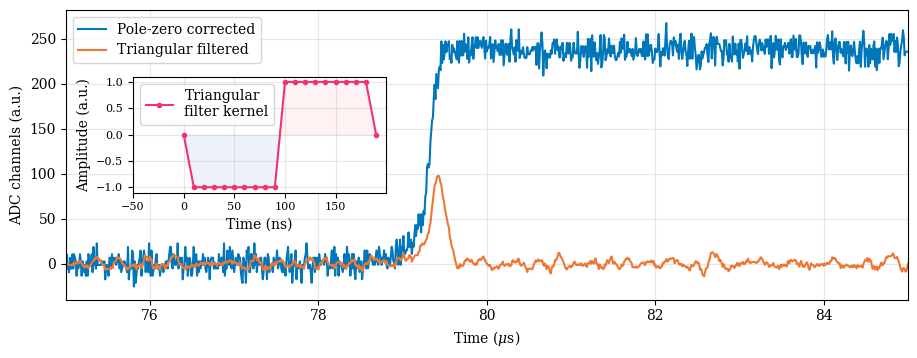

In [20]:
rise = 0.096
flat = 0
fall = rise
padding = 0
dt = 0.01
height=1
shift = 0

kernel = np.array(
    [0]*int(padding/2/dt-shift+1) + [-height]*int(fall/dt) + [0]*int(flat/dt) + [+height]*int(rise/dt) + [0]*int(padding/2/dt+1+shift)
)

fig, ax = plt.subplots()

# main panel
ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], label="Pole-zero corrected")
ax.plot(ts_windowed_values, proc_tb.wf_tri.values[i], label="Triangular filtered")

# inset - filter kernel
ax_inset = ax.inset_axes([0.08, 0.37, 0.3, 0.4])  # [x, y, width, height] in axes coordinates
xk = np.arange(len(kernel)) * 10
ax_inset.plot(xk, kernel, color="C3", marker='.', label="Triangular\nfilter kernel")
ax_inset.set_xlim(-50, None)
ax_inset.set_xlabel("Time (ns)", fontsize=10)
ax_inset.set_ylabel("Amplitude (a.u.)")
ax_inset.tick_params(labelsize=8)
ax_inset.fill_between(
    xk, 0, kernel, where=(kernel < 0), interpolate=True, step="mid",
    color=tc.pale[0], alpha=0.25
)
ax_inset.fill_between(
    xk, 0, kernel, where=(kernel > 0), interpolate=True, step="mid",
    color=tc.pale[1], alpha=0.25
)
ax_inset.legend(loc='upper left')

ax.legend(loc='upper left')
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_for_A_max_tri_estimation.pdf")

### A_max_mw

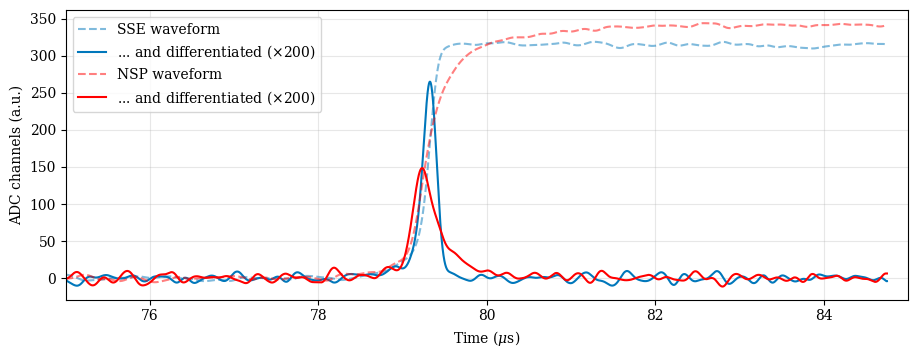

In [25]:
# i1 = 7# mse
i1 = 76 #sse
i1 = 39
i2 = 64 #sp

length = 0.1
height = dt/length
padding = 15
n_convolutions = 4
one_pass_kernel = np.array([0]*padding + [height] * int(length / dt) + [0]*padding, dtype=float)

# 5-fold self-convolution (kernel convolved with itself to total 5 factors)
kernel = one_pass_kernel.copy()
two_pass_kernel = np.convolve(one_pass_kernel, one_pass_kernel, mode="same")
for _ in range(n_convolutions):
    kernel = np.convolve(kernel, one_pass_kernel, mode="same")
five_pass_kernel = kernel

fig, ax = plt.subplots()
# manually align averaged waveform correctly
ts_windowed_values_av = ts_windowed_values - 0.25
x_vals_up = np.linspace(ts_windowed_values[0], ts_windowed_values[-1], 10000) - 0.25
x_vals_up_diff = np.linspace(ts_windowed_values[0], ts_windowed_values[-1], 9990) -0.25

# main panel
ax.plot([], [])
# ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i1], color="grey", label="Pole-zero corrected",alpha=0.5)
# ax.plot(ts_windowed_values_av, proc_tb.wf_mwavg_win.values[i1],color="C0", label="... and smoothed",alpha=0.5)
# ax.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i1],color="C0",linestyle="--", label="... and upsampled & interpolated",alpha=0.5)
ax.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i1],color="C0",linestyle="--", label="SSE waveform",alpha=0.5)
ax.plot(x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i1],color="C0", label="... and differentiated"+r" ($\times$200)")
# ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i2], color="grey", label="Pole-zero corrected",alpha=0.5)
# ax.plot(ts_windowed_values_av, proc_tb.wf_mwavg_win.values[i2], color="C1", label="... and smoothed",alpha=0.5)
# ax.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i2], color="red",linestyle='--', label="... and upsampled & interpolated",alpha=0.5)
ax.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i2], color="red",linestyle='--', label="NSP waveform",alpha=0.5)

ax.plot(x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i2], color="red", label="... and differentiated"+r" ($\times$200)")

# inset
# ax_inset = ax.inset_axes([0.7, 0.32, 0.27, 0.40])  # [x, y, width, height] in axes coordinates
# ax_inset.plot([], [])
# ax_inset.plot(ts_windowed_values_av, proc_tb.wf_mwavg_win.values[i], marker=".")
# ax_inset.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i], marker=".")

# ax_inset.set_xlim(78.75, 78.8)
# ax_inset.set_ylim(0, 10)
# ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
# ax_inset.set_ylabel("ADC ch. (a.u.)", fontsize=10)
# ax_inset.tick_params(labelsize=8)

## inset - filter kernel
#ax_inset2 = ax.inset_axes([0.08, 0.32, 0.3, 0.4])  # [x, y, width, height] in axes coordinates
#ax_inset2.plot(np.arange(len(one_pass_kernel)) * dt, one_pass_kernel, color="C3", marker='.', label="1 pass")
#ax_inset2.plot(np.arange(len(two_pass_kernel)) * dt, two_pass_kernel, color="C4", marker='.', label="2 pass")
#ax_inset2.plot(np.arange(len(five_pass_kernel)) * dt, five_pass_kernel, color="C5", marker='.', label=f"{n_convolutions+1} pass")
#ax_inset2.set_xlabel(r"Time ($\mu$s)", fontsize=10)
#ax_inset2.set_ylabel("Amplitude (a.u.)")
#ax_inset2.tick_params(labelsize=8)
#ax_inset2.legend(title="MWA kernels")

ax.legend(loc='upper left')
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))

fig.tight_layout()
# fig.savefig(plot_loc+"waveform_for_A_max_mw_estimation.pdf")

### Comparison of A_max, A_max_tri, and A_max_mw

FileNotFoundError: [Errno 2] No such file or directory: '../plots/phd/waveforms_for_current_estimation.pdf'

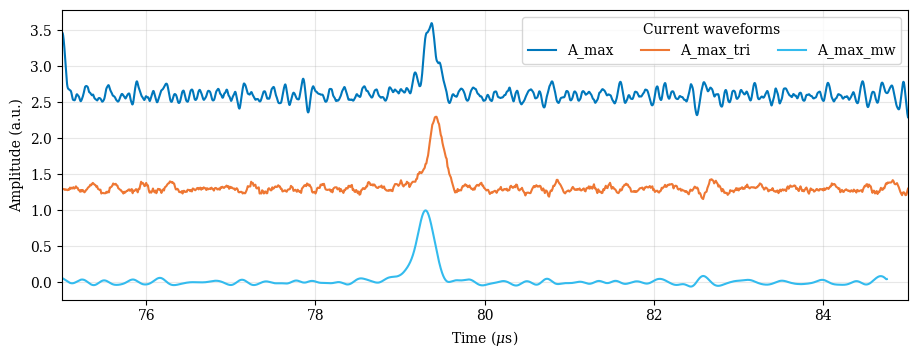

In [22]:
fig, ax = plt.subplots()
amp = 1
vshift = 1.3
# manually align averaged waveform correctly
x_vals_up = np.linspace(ts_windowed_values[1], ts_windowed_values[-1], 9990)
x_vals_up_diff = np.linspace(ts_windowed_values[0], ts_windowed_values[-1], 9990) - 0.25

# main panel
#ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], label="Pole-zero corrected")
ax.plot(x_vals_up, proc_tb.curr_av_win.values[i]/np.max(proc_tb.curr_av_win.values[i])*amp+2*vshift, label="A_max")
ax.plot(ts_windowed_values, proc_tb.wf_tri.values[i]/np.max(proc_tb.wf_tri.values[i])*amp+vshift, label="A_max_tri")
ax.plot(x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i]/np.max(proc_tb.wf_mwavg_up_curr_win.values[i])*amp, label="A_max_mw")


ax.legend(loc='upper right', ncols=3, title="Current waveforms")
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))

fig.tight_layout()
fig.savefig(plot_loc+"waveforms_for_current_estimation.pdf")

## Integral asymmetry parameter

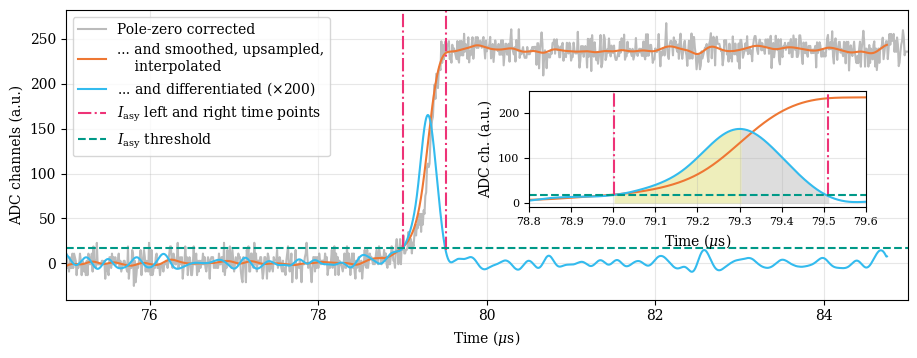

In [ ]:
xrange_inset = (78.8, 79.6)
yrange_inset = (-10, 250)

fig, ax = plt.subplots()
# manually align averaged waveform correctly
ts_windowed_values_av = ts_windowed_values - 0.25
x_vals_up = np.linspace(ts_windowed_values[0], ts_windowed_values[-1], 10000) - 0.25
x_vals_up_diff = np.linspace(ts_windowed_values[0], ts_windowed_values[-1], 9990) -0.25

# main panel
ax.plot([], [])
ax.plot(ts_windowed_values, proc_tb.wf_pz_win.values[i], color="C6", label="Pole-zero corrected")
ax.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i], label="... and smoothed, upsampled,\n    interpolated")
ax.plot(x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i], label="... and differentiated"+r" ($\times200$)")

# vertical lines from top down to the current waveform
tp_A_max_x = proc_tb.tp_A_max_mw[i]/1e3
tp_left_x = proc_tb.tp_Iasy_left[i]/1e3
tp_right_x = proc_tb.tp_Iasy_right[i]/1e3

curr_y_A_max = np.interp(tp_A_max_x, x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i])
curr_y_left = np.interp(tp_left_x, x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i])
curr_y_right = np.interp(tp_right_x, x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i])

ytop = ax.get_ylim()[1]
#ax.vlines(tp_A_max_x, ymin=curr_y_A_max, ymax=ytop, ls="-.", color="C3", label=r"$I_\mathrm{asy}$ time points")
#ax.axvline(tp_A_max_x, color="black", label="Maximal current time point")
ax.vlines(tp_left_x, ymin=curr_y_left, ymax=ytop, ls="-.", color="C3", label=r"$I_\mathrm{asy}$ left and right time points")
ax.vlines(tp_right_x, ymin=curr_y_right, ymax=ytop, ls="-.", color="C3")
ax.axhline(proc_tb.Iasy_threshold[i], color="C5", ls="--", label=r"$I_\mathrm{asy}$ threshold")
ax.set_ylim(None, ytop)

# inset
ax_inset = ax.inset_axes([0.55, 0.32, 0.4, 0.40])  # [x, y, width, height] in axes coordinates
ax_inset.plot([], [])
ax_inset.plot(x_vals_up, proc_tb.wf_mwavg_up_win.values[i])
ax_inset.plot(x_vals_up_diff, proc_tb.wf_mwavg_up_curr_win.values[i])

ytop = yrange_inset[1]
#ax_inset.vlines(tp_A_max_x, ymin=curr_y_A_max, ymax=ytop, ls="-.", color="C3")
#ax_inset.axvline(tp_A_max_x, color="black")
ax_inset.vlines(tp_left_x, ymin=curr_y_left, ymax=ytop, ls="-.", color="C3")
ax_inset.vlines(tp_right_x, ymin=curr_y_right, ymax=ytop, ls="-.", color="C3")
ax_inset.axhline(proc_tb.Iasy_threshold[i], color="C5", ls="--")

# Color the Iasy areas
mask = (x_vals_up_diff >= tp_left_x) & (x_vals_up_diff <= tp_A_max_x)
ax_inset.fill_between(x_vals_up_diff[mask], 0, proc_tb.wf_mwavg_up_curr_win.values[i][mask], color=tc.pale[3])
mask = (x_vals_up_diff >= tp_A_max_x) & (x_vals_up_diff <= tp_right_x)
ax_inset.fill_between(x_vals_up_diff[mask], 0, proc_tb.wf_mwavg_up_curr_win.values[i][mask], color=tc.pale[5])



ax_inset.set_xlim(xrange_inset)
ax_inset.set_ylim(yrange_inset)
ax_inset.set_xlabel(r"Time ($\mu$s)", fontsize=10)
ax_inset.set_ylabel("ADC ch. (a.u.)", fontsize=10)
ax_inset.tick_params(labelsize=8)

ax.legend(loc='upper left')
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")
ax.set_xlim(minmax(ts_windowed_values))

fig.tight_layout()
fig.savefig(plot_loc+"waveform_for_Iasy_estimation.pdf")